Generating a synthetic signal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings      # Not used directly in the code but generally used for handling warnings


def get_signal_Hz(Hz,sample_rate,length_ts_sec):# Frequency of the sine wave, Number of samples per second, Duration of the signal in seconds.
    ## 1 sec length time series with sampling rate
    ts1sec = list(np.linspace(0,np.pi*2*Hz,sample_rate))   # Creates a time series for 1 sec. using np. linspace to sample points between 0 ti 2pi
    ## 1 sec length time series with sampling rate         # ensuring one full cycle of the sine wave at the given frequency.
    ts = ts1sec*length_ts_sec                   # Repeats the time series for the specified length_ts_sec
    return(list(np.sin(ts)))                    # Generates a sine wave (np.sin)

sample_rate   = 4000
length_ts_sec = 3
## --------------------------------- ##
## 3 seconds of "digit 1" sound
## Pressing digit 1 buttom generates
## the sine waves at frequency
## 697Hz and 1209Hz.   pressing the "1" key sends a combination of the 697 Hz low tone and the 1209 Hz high tone
# Two sine waves at these frequencies are generated and added together.
## -----------------------------------##
ts1  = np.array(get_signal_Hz(697, sample_rate,length_ts_sec))
ts1 += np.array(get_signal_Hz(1209,sample_rate,length_ts_sec))
ts1  = list(ts1)

## -------------------- ##
## 1 seconds of silence
## -------------------- ##
ts_silence = [0]*sample_rate*1    # A 1-second silence (array of zeros) is created

## --------------------------------- ##
## 3 seconds of "digit 2" sounds
## Pressing digit 2 buttom generates
## the sine waves at frequency
## 697Hz and 1336Hz.
## --------------------------------- ##
ts2  = np.array(get_signal_Hz(697, sample_rate,length_ts_sec))
ts2 += np.array(get_signal_Hz(1336,sample_rate,length_ts_sec))
ts2  = list(ts2)

## -------------------- ##
## Add up to 7 seconds
## ------------------- ##
ts = ts1 + ts_silence  + ts2   # for digit '3' Dual-Tone Multi-Frequency (DTMF) frequencies 1336 Hz and 1477 Hz

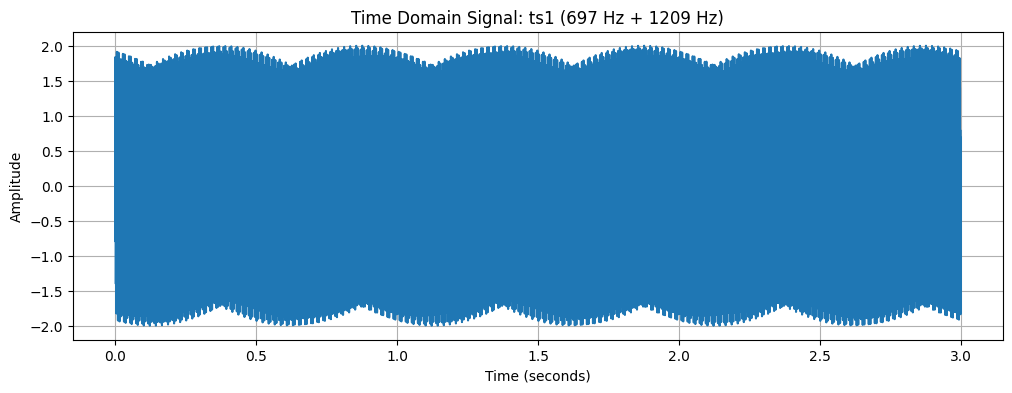

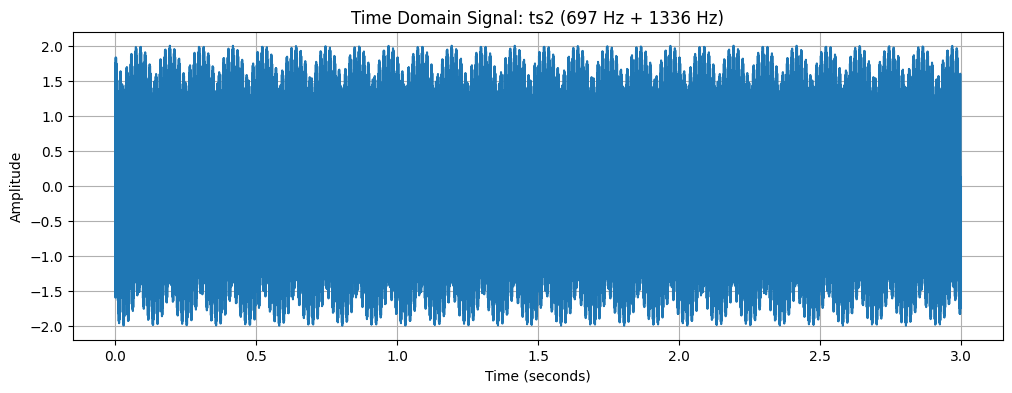

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists to numpy arrays (safe practice)
ts1 = np.array(ts1)
ts2 = np.array(ts2)

# Create time axis (in seconds)
t = np.arange(len(ts1)) / sample_rate

# Plot time-domain signal for ts1
plt.figure(figsize=(12, 4))
plt.plot(t, ts1)
plt.title("Time Domain Signal: ts1 (697 Hz + 1209 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Create time axis (in seconds)
t = np.arange(len(ts2)) / sample_rate

# Plot time-domain signal for ts2
plt.figure(figsize=(12, 4))
plt.plot(t, ts2)
plt.title("Time Domain Signal: ts2 (697 Hz + 1336 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


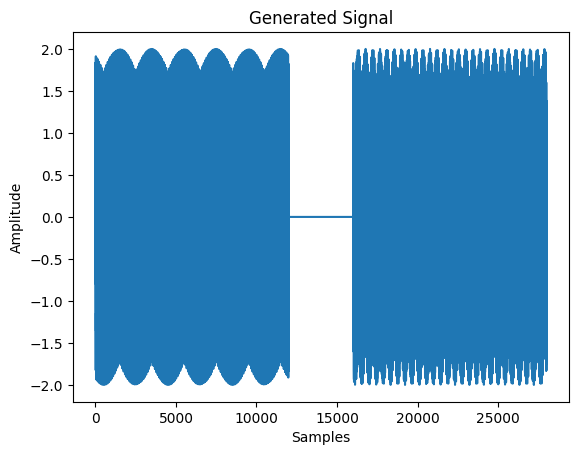

In [ ]:
plt.plot(ts[:sample_rate*7])  # Plot first 7 seconds of the signal
plt.title("Generated Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")  # Sample rate is 4000 and duration is 7 sec. Total sample ?
plt.show()


In [ ]:
from IPython.display import Audio
audio=Audio(ts, rate=sample_rate)
audio

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays
ts1 = np.array(ts1)
ts2 = np.array(ts2)

N = len(ts1)                  # Number of samples
fs = sample_rate              # Sampling frequency

# Frequency axis
freqs = np.fft.fftfreq(N, d=1/fs)

# FFT computation
fft_ts1 = np.fft.fft(ts1)
fft_ts2 = np.fft.fft(ts2)


Spectrogram from Scratch
A short-time Fourier transform (STFT) is the effect of windowing a signal and calculating its discrete Fourier transform (DFT).
Spectrogram is the magnitude of the STFT.

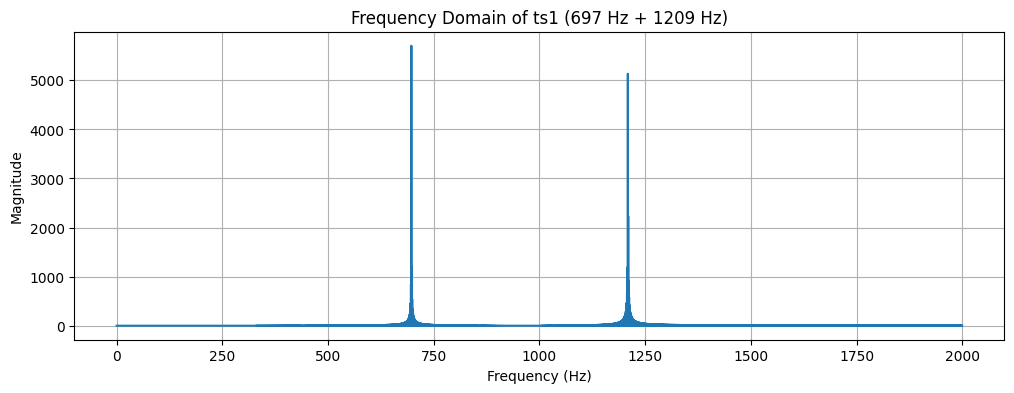

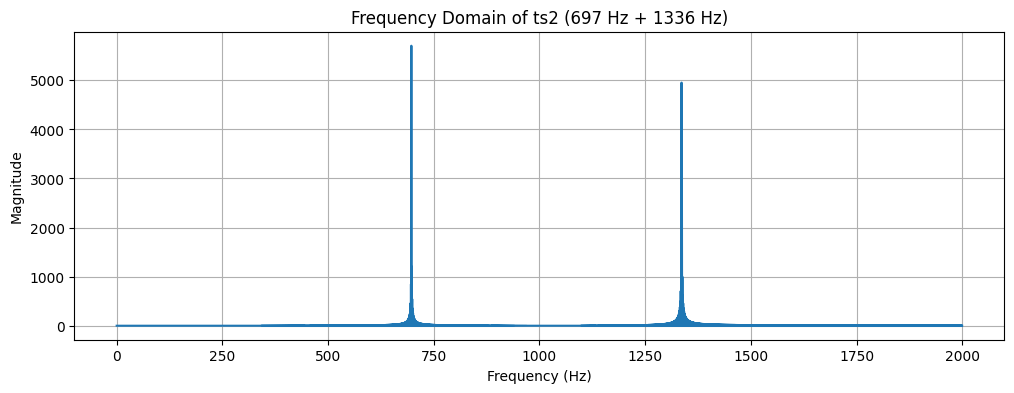

In [ ]:
# Take only positive frequencies
half_N = N // 2

plt.figure(figsize=(12, 4))
plt.plot(freqs[:half_N], np.abs(fft_ts1[:half_N]))
plt.title("Frequency Domain of ts1 (697 Hz + 1209 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(freqs[:half_N], np.abs(fft_ts2[:half_N]))
plt.title("Frequency Domain of ts2 (697 Hz + 1336 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:8233: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


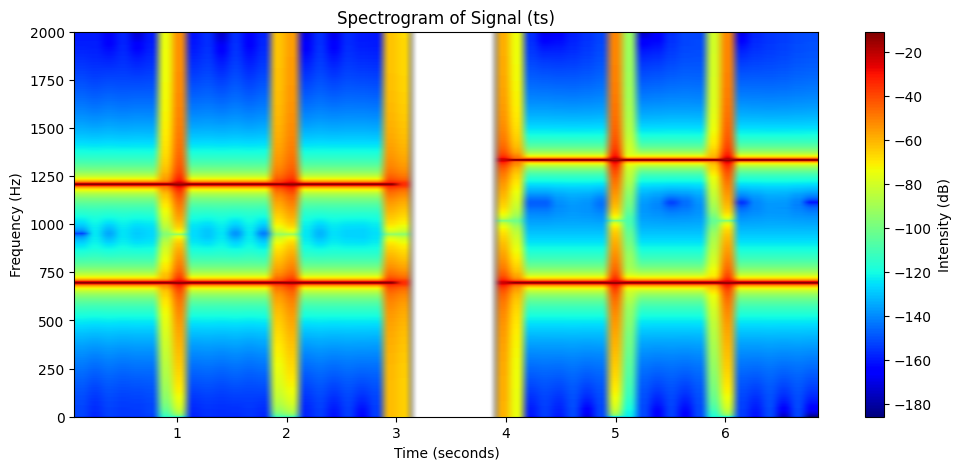

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert full signal to numpy array
ts = np.array(ts)
fs = sample_rate
plt.figure(figsize=(12, 5))

plt.specgram(
    ts,
    NFFT=1024,        # Window size
    Fs=fs,            # Sampling frequency
    noverlap=512,     # Overlap between windowsNumber of samples shared between adjacent frames
    cmap="jet"
)

plt.title("Spectrogram of Signal (ts)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")
plt.show()


The total time series length = 7.0 sec (N points = 28000) 


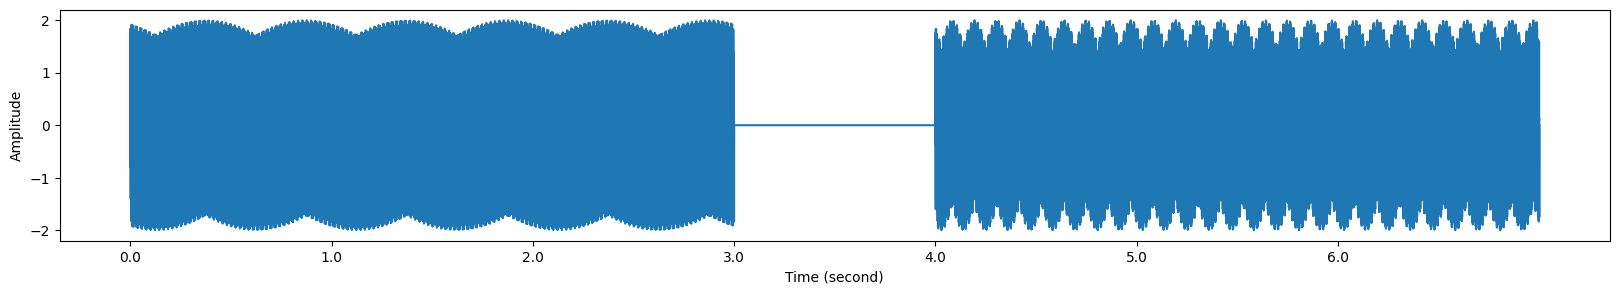

In [ ]:
total_ts_sec = len(ts)/sample_rate   #Total Time-Series Length Calculation, sample rate = 4000 and len(ts) returns total no of data points 28000
print("The total time series length = {} sec (N points = {}) ".format(total_ts_sec, len(ts)))
plt.figure(figsize=(20,3))
plt.plot(ts)
plt.xticks(np.arange(0,len(ts),sample_rate),    #reates an array of sample indices, from 0 to the total number of samples spaced by sample_rate
           np.arange(0,len(ts)/sample_rate,1))  # Creates an array of time labels in seconds, These arrays are used to label the x-axis
plt.ylabel("Amplitude")
plt.xlabel("Time (second)")
plt.show()



*Q1: Convert the above signal to frequency vs time.*

In [ ]:
import numpy as np
from scipy import signal
from scipy.fft import fftshift
import matplotlib.pyplot as plt

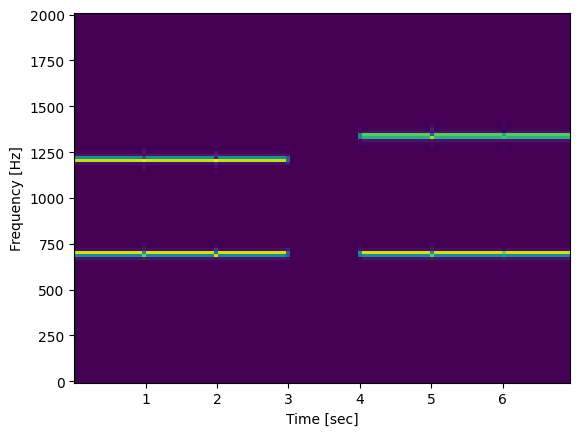

In [ ]:
f, t, Sxx = signal.spectrogram(np.array(ts), 4000)  # A function from the scipy.signal module that computes the spectrogram of a signal.
# f is Array of frequencies (in Hz), t is Array of time points, Sxx represent the intensity of the signal at a specific frequency and time.
# represent the intensity of the signal at a specific frequency and time.  sampling rate of the signal in Hz is 4000
plt.pcolormesh(t, f, Sxx)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

During the first 3 seconds (tone for "digit 1"), you will see strong intensities at 697 Hz and 1209 Hz.
During the 1-second silence, no significant intensities appear.
During the next 3 seconds (tone for "digit 2"), strong intensities appear at 697 Hz and 1336 Hz.

Bright color suggests that the frequency is dominant or highly active in the signal during that time segment.
Darker color suggest that the frequency is less active or absent in the signal at that time.

In [ ]:
import librosa
import librosa.display
import IPython.display as ipd

In [ ]:
audio_data=np.array(ts)

In [ ]:
stft_audio = librosa.stft(audio_data, n_fft = 4000, hop_length = 2048)

<ipython-input-9-e875c99ada3c>:1: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(stft_audio, sr = 4000, hop_length = 2048, x_axis = "time", y_axis = "linear")


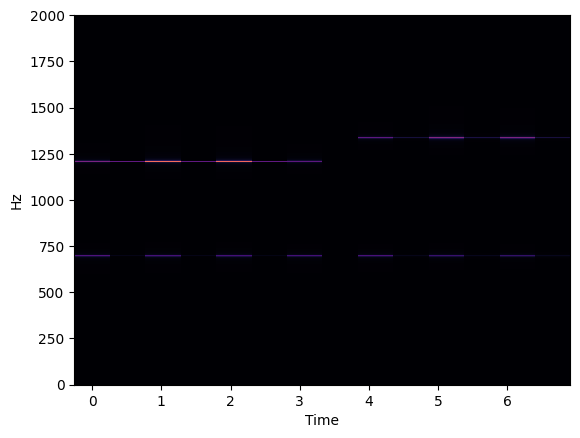

In [ ]:
librosa.display.specshow(stft_audio, sr = 4000, hop_length = 2048, x_axis = "time", y_axis = "linear")

*Q2. Plot the spectrogram of a .wav file.*

<ipython-input-10-d1a0bbdfd799>:19: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D = librosa.amplitude_to_db(librosa.stft(y), ref=np.max)  # Short-Time Fourier Transform (STFT)


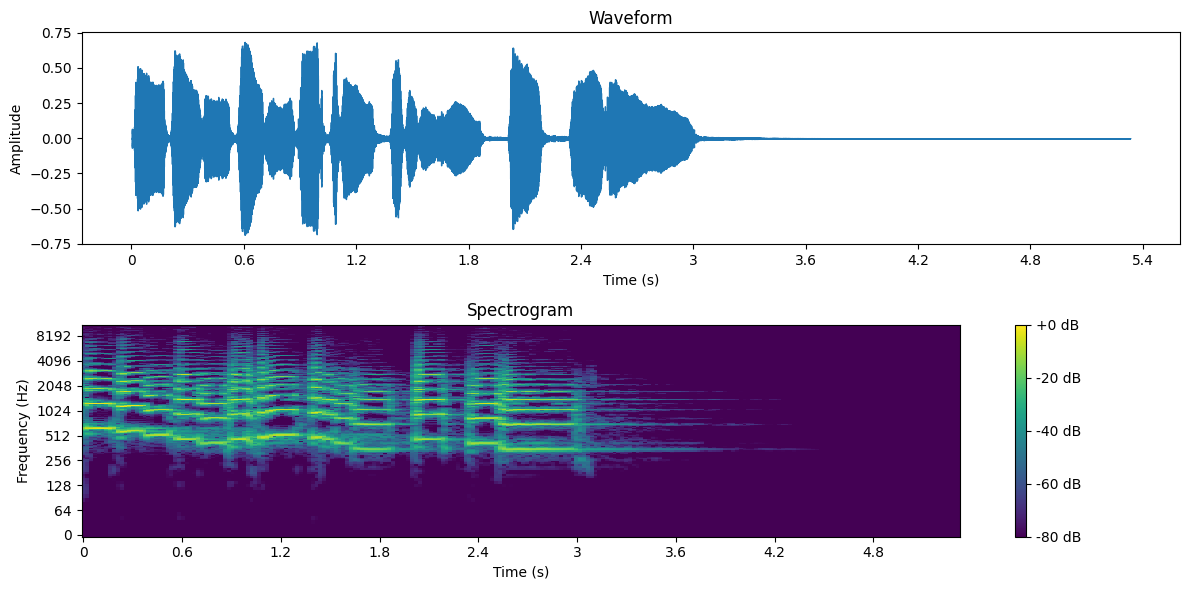

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the audio file
audio_file = librosa.example('trumpet')  # Example audio file from Librosa  OR '/content/M04_B2_LE_M6.wav' OR brahms
y, sr = librosa.load(audio_file, sr=None)  # Load audio with original sampling rate

# Plot the waveform
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Compute the spectrogram
D = librosa.amplitude_to_db(librosa.stft(y), ref=np.max)  # Short-Time Fourier Transform (STFT)

# Plot the spectrogram
plt.subplot(2, 1, 2)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

# Show the plots
plt.tight_layout()
plt.show()


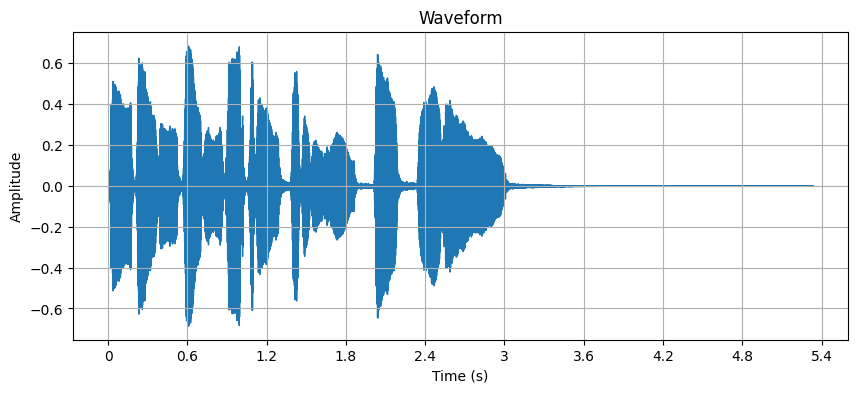

Audio Duration: 5.33 seconds


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load an audio file
audio_file = librosa.example('trumpet')   # Example file from Librosa
y, sr = librosa.load(audio_file)

# Display the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Calculate and print the duration
duration = librosa.get_duration(y=y, sr=sr)
print(f"Audio Duration: {duration:.2f} seconds")
